In [ ]:
import sys
!"{sys.executable}" -m pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/processed/exoplanet_cleaned.csv")

df['habitable'] = (df['habitability_score'] >= 0.45).astype(int)


In [5]:

df['habitable'].value_counts()


habitable
0    38179
1     1033
Name: count, dtype: int64

In [6]:
features = [
    'pl_rade',
    'pl_eqt',
    'pl_orbper',
    'st_teff',
    'stellar_compatibility'
]

X = df[features]
y = df['habitable']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [8]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = {}
best_model = None
best_score = 0


In [9]:
for name, model in models.items():

    pipeline = Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc
    }

    print(f"\n{name} Results")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("ROC-AUC:", roc)

    if roc > best_score:
        best_score = roc
        best_model = pipeline



Random Forest Results
Accuracy: 0.9993624888435547
Precision: 0.9855769230769231
Recall: 0.9903381642512077
F1: 0.9879518072289156
ROC-AUC: 0.9999955714477318

Logistic Regression Results
Accuracy: 0.9853372434017595
Precision: 0.8709677419354839
Recall: 0.5217391304347826
F1: 0.6525679758308157
ROC-AUC: 0.9929339285307581

XGBoost Results
Accuracy: 0.9977049598367972
Precision: 0.9565217391304348
Recall: 0.9565217391304348
F1: 0.9565217391304348
ROC-AUC: 0.9998665107816269


In [10]:
results_df = pd.DataFrame(results).T
results_df


,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.999362,0.985577,0.990338,0.987952,0.999996
Logistic Regression,0.985337,0.870968,0.521739,0.652568,0.992934
XGBoost,0.997705,0.956522,0.956522,0.956522,0.999867


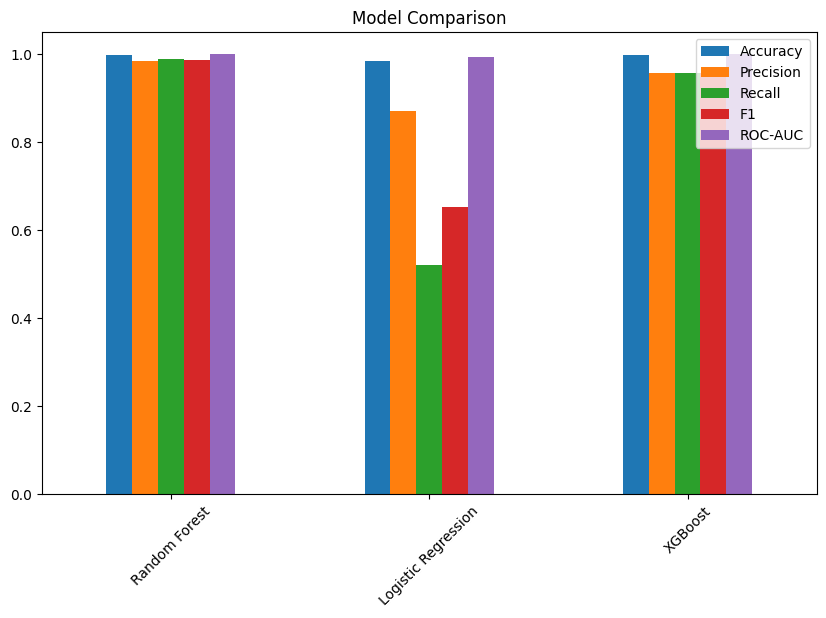

In [11]:
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()


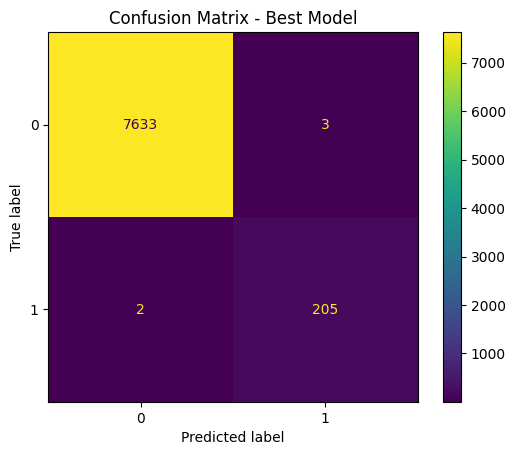

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Best Model")
plt.show()


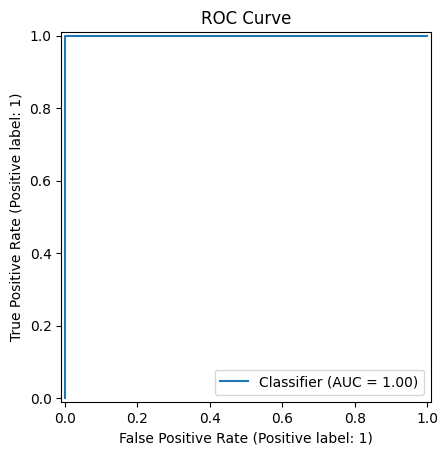

In [13]:
from sklearn.metrics import RocCurveDisplay

y_prob = best_model.predict_proba(X_test)[:,1]

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()


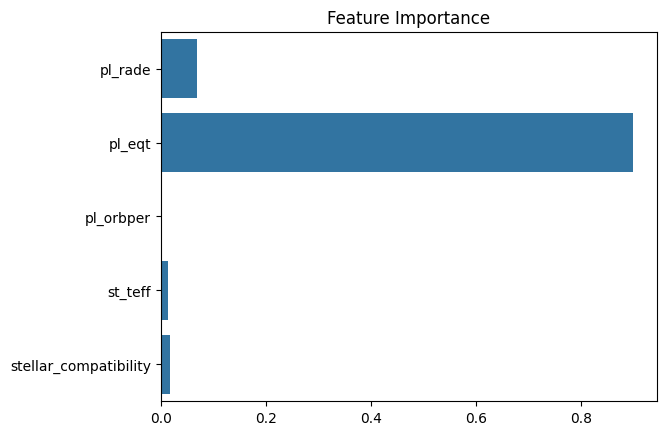

In [14]:
model = best_model.named_steps['model']

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_

    sns.barplot(x=importances, y=features)
    plt.title("Feature Importance")
    plt.show()


In [15]:
df['probability'] = best_model.predict_proba(X)[:,1]

df['habitability_rank'] = df['probability'].rank(ascending=False)

ranked_planets = df.sort_values(by='probability', ascending=False)

ranked_planets[['pl_rade','pl_eqt','probability']].head(10)


,pl_rade,pl_eqt,probability
11373,0.000229,0.443227,1.0
30509,0.000100,0.467629,1.0
2274,0.000243,0.521912,1.0
30474,0.000752,0.400149,1.0
30468,0.000752,0.400149,1.0
30467,0.000752,0.400149,1.0
12777,0.000194,0.423805,1.0
30425,0.000269,0.424801,1.0
20048,0.000308,0.436006,1.0
30361,0.000764,0.422311,1.0


In [16]:
import joblib

joblib.dump(best_model, "../models/best_model.pkl")

print("Best model saved")


Best model saved


## Week 4: Model Development and Evaluation

In this phase, multiple machine learning models were trained and evaluated
to predict the habitability of exoplanets.

### Models Used
- Random Forest Classifier
- Logistic Regression
- XGBoost Classifier

### Evaluation Metrics
The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

ROC-AUC was considered the primary metric as it provides a balanced
evaluation for classification problems.

### Model Comparison
A comparative analysis was performed to identify the best-performing model.

### Feature Importance
Feature importance analysis was conducted to understand the influence
of planetary and stellar parameters on habitability.

### Planet Ranking
Exoplanets were ranked based on predicted habitability probabilities,
allowing prioritization for further astronomical research.

### Conclusion
The best-performing model was selected and saved for deployment in the
backend system.
